## Import Libraries ##

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from skimage import exposure

from sklearn.svm import SVC
from sklearn.model_selection import (train_test_split, 
                                     GridSearchCV, 
                                     StratifiedKFold,
                                     cross_val_score)
from sklearn.metrics import (accuracy_score, 
                             precision_score,
                             recall_score, 
                             f1_score, 
                             confusion_matrix,
                             classification_report)

import warnings
warnings.filterwarnings('ignore')

## Load Dataset ##

In [34]:
print("Loading dataset...")

df_train = pd.read_csv('emnist-letters-train.csv', header=None)
df_test  = pd.read_csv('emnist-letters-test.csv',  header=None)

# Gabungkan semua data dulu sebelum sampling
df_all = pd.concat([df_train, df_test], ignore_index=True)

print(f"Total keseluruhan data : {len(df_all):,} baris")
print(f"Jumlah kolom           : {df_all.shape[1]}")
print(f"Kolom 0                : class label")
print(f"Kolom 1-784            : pixel values (28x28)")
print(f"Unique classes         : {sorted(df_all[0].unique())}")

Loading dataset...
Total keseluruhan data : 103,600 baris
Jumlah kolom           : 785
Kolom 0                : class label
Kolom 1-784            : pixel values (28x28)
Unique classes         : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]


## Sampling 2600 Balanced + Shuffle ##

In [ ]:
SAMPLES_PER_CLASS = 100
NUM_CLASSES       = 26
RANDOM_STATE      = 42

# Label mapping: 1→A, 2→B, ..., 26→Z
label_map = {i: chr(64 + i) for i in range(1, 27)}


# Shuffle seluruh dataset terlebih dulu

df_all = df_all.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(" Dataset sudah di-shuffle")


# Ambil 100 sampel per kelas (balanced)

balanced_parts = []

for label in range(1, NUM_CLASSES + 1):
    class_data = df_all[df_all[0] == label].head(SAMPLES_PER_CLASS)
    balanced_parts.append(class_data)
    print(f"  Kelas {label_map[label]} ({label}) : {len(class_data)} sampel")

balanced_df = pd.concat(balanced_parts, ignore_index=True)

# Shuffle lagi setelah digabung

balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"\n 1. Total sampel setelah balanced : {len(balanced_df)}")
print(f" 2. Dataset di-shuffle ulang setelah digabung")

 Dataset sudah di-shuffle
  Kelas A (1) : 100 sampel
  Kelas B (2) : 100 sampel
  Kelas C (3) : 100 sampel
  Kelas D (4) : 100 sampel
  Kelas E (5) : 100 sampel
  Kelas F (6) : 100 sampel
  Kelas G (7) : 100 sampel
  Kelas H (8) : 100 sampel
  Kelas I (9) : 100 sampel
  Kelas J (10) : 100 sampel
  Kelas K (11) : 100 sampel
  Kelas L (12) : 100 sampel
  Kelas M (13) : 100 sampel
  Kelas N (14) : 100 sampel
  Kelas O (15) : 100 sampel
  Kelas P (16) : 100 sampel
  Kelas Q (17) : 100 sampel
  Kelas R (18) : 100 sampel
  Kelas S (19) : 100 sampel
  Kelas T (20) : 100 sampel
  Kelas U (21) : 100 sampel
  Kelas V (22) : 100 sampel
  Kelas W (23) : 100 sampel
  Kelas X (24) : 100 sampel
  Kelas Y (25) : 100 sampel
  Kelas Z (26) : 100 sampel

 1. Total sampel setelah balanced : 2600
 2. Dataset di-shuffle ulang setelah digabung


## Preprocessing Gambar ##

In [36]:
# Pisahkan label dan pixel
labels_raw = balanced_df[0].values           # (2600,)
pixels     = balanced_df.iloc[:, 1:].values  # (2600, 784)

# Reshape → 28x28
# EMNIST disimpan column-major, perlu di-transpose
images = pixels.reshape(-1, 28, 28)
images = np.transpose(images, (0, 2, 1))  # fix orientasi EMNIST

# Label string untuk display
label_names = np.array([label_map[l] for l in labels_raw])

print(f"Shape images : {images.shape}")
print(f"Shape labels : {labels_raw.shape}")
print(f"Min pixel    : {images.min()}")
print(f"Max pixel    : {images.max()}")
print(f"Contoh label : {label_names[:10]}")

Shape images : (2600, 28, 28)
Shape labels : (2600,)
Min pixel    : 0
Max pixel    : 255
Contoh label : ['P' 'B' 'C' 'V' 'P' 'T' 'Q' 'E' 'H' 'U']


## Visualisasi Sample Gambar per Kelas ##

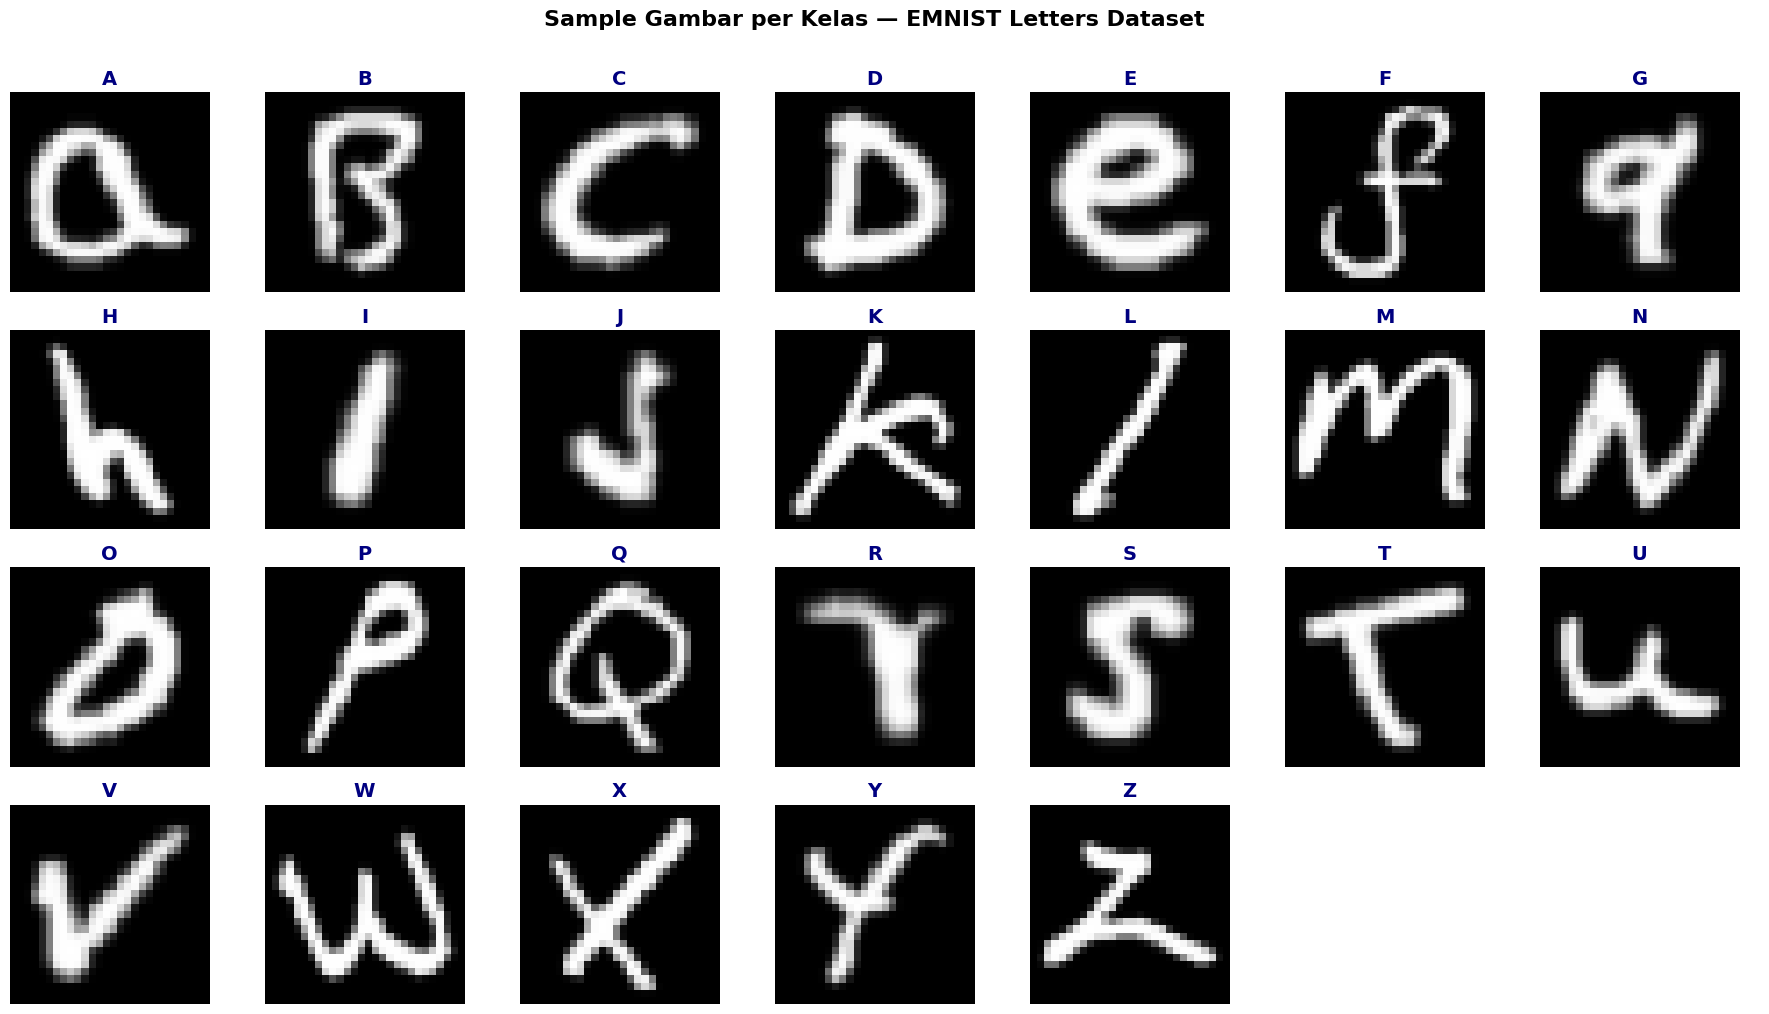

In [37]:
fig, axes = plt.subplots(4, 7, figsize=(18, 10))
axes = axes.flatten()

for i in range(NUM_CLASSES):
    label_val = i + 1
    idx = np.where(labels_raw == label_val)[0][0]
    
    axes[i].imshow(images[idx], cmap='gray')
    axes[i].set_title(f'{label_map[label_val]}', 
                      fontsize=14, fontweight='bold', color='navy')
    axes[i].axis('off')

# Sembunyikan sisa axes
for j in range(NUM_CLASSES, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Gambar per Kelas — EMNIST Letters Dataset', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

 ## HOG Feature Extraction ##

In [38]:
# =============================================
# Parameter HOG (diubah dari default)
# Default orientations   = 9   → kita pakai 12
# Default pixels_per_cell= (8,8) → kita pakai (7,7)
# Default cells_per_block= (3,3) → kita pakai (2,2)
# =============================================

HOG_ORIENTATIONS    = 12
HOG_PIXELS_PER_CELL = (7, 7)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_BLOCK_NORM      = 'L2-Hys'

def extract_hog_features(images, orientations, pixels_per_cell, 
                          cells_per_block, block_norm):
    features = []
    for img in images:
        # Normalisasi ke 0.0 - 1.0
        img_norm = img.astype(np.float32) / 255.0
        
        feat = hog(
            img_norm,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm=block_norm,
            visualize=False
        )
        features.append(feat)
    return np.array(features)


X = extract_hog_features(
    images,
    orientations=HOG_ORIENTATIONS,
    pixels_per_cell=HOG_PIXELS_PER_CELL,
    cells_per_block=HOG_CELLS_PER_BLOCK,
    block_norm=HOG_BLOCK_NORM
)

y = labels_raw

print(f"   Orientations    : {HOG_ORIENTATIONS}")
print(f"   Pixels per cell : {HOG_PIXELS_PER_CELL}")
print(f"   Cells per block : {HOG_CELLS_PER_BLOCK}")
print(f"   Block norm      : {HOG_BLOCK_NORM}")
print(f"   Shape features  : {X.shape}")
print(f"   Fitur per gambar: {X.shape[1]}")

   Orientations    : 12
   Pixels per cell : (7, 7)
   Cells per block : (2, 2)
   Block norm      : L2-Hys
   Shape features  : (2600, 432)
   Fitur per gambar: 432


## Visualisasi HOG ##

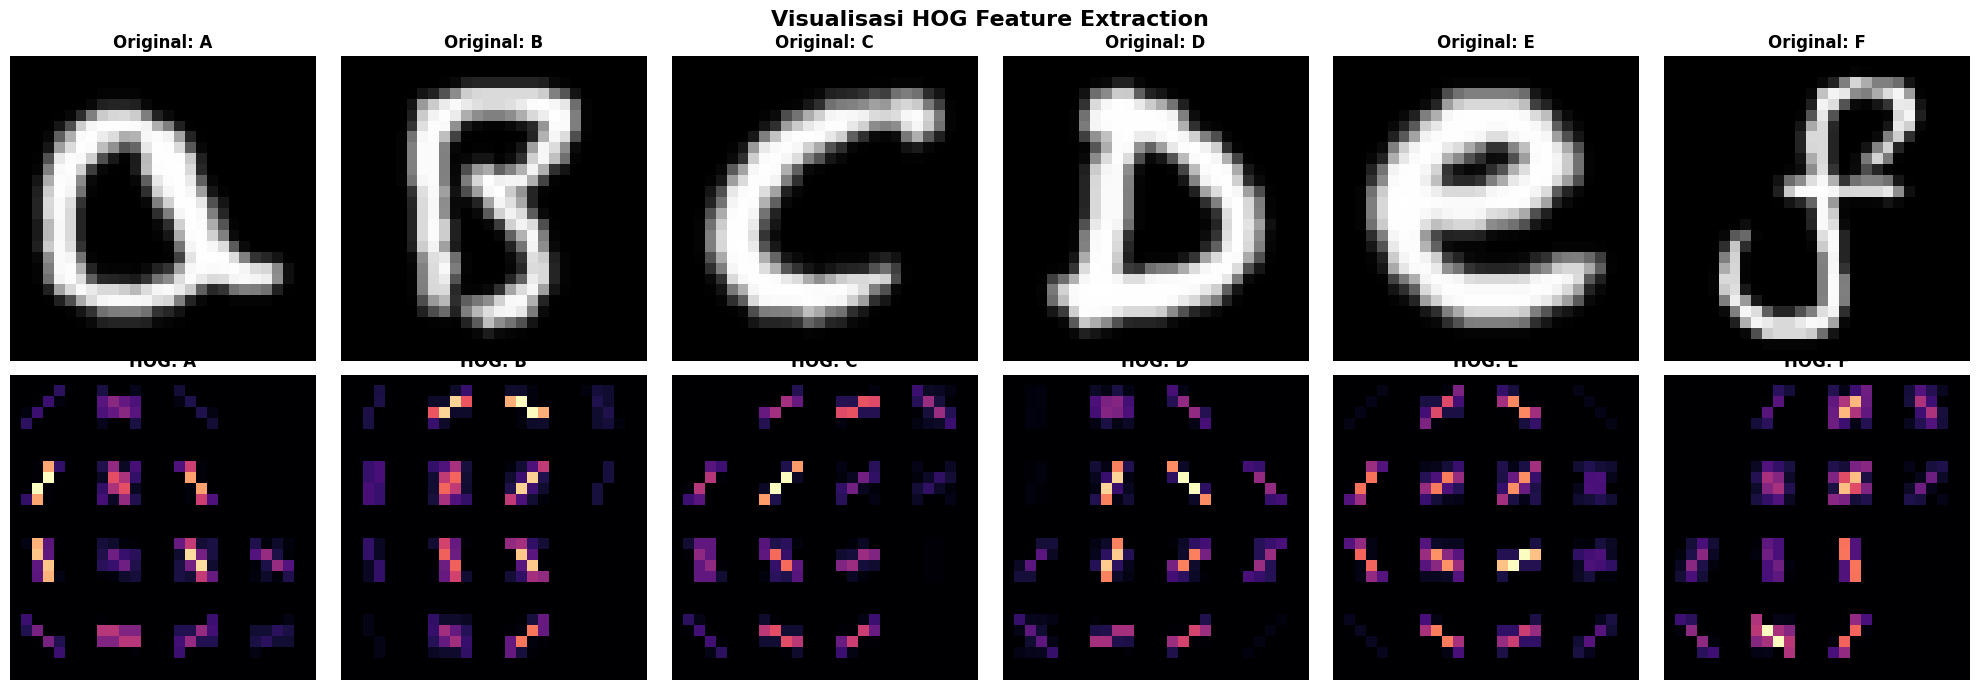

In [39]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

sample_labels = [1, 2, 3, 4, 5, 6]  # A, B, C, D, E, F

for col, label_val in enumerate(sample_labels):
    idx = np.where(labels_raw == label_val)[0][0]
    img_norm = images[idx].astype(np.float32) / 255.0
    
    _, hog_image = hog(
        img_norm,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm=HOG_BLOCK_NORM,
        visualize=True
    )
    
    hog_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    
    # Baris atas: gambar asli
    axes[0, col].imshow(images[idx], cmap='gray')
    axes[0, col].set_title(f'Original: {label_map[label_val]}', 
                           fontweight='bold', fontsize=12)
    axes[0, col].axis('off')
    
    # Baris bawah: HOG
    axes[1, col].imshow(hog_rescaled, cmap='magma')
    axes[1, col].set_title(f'HOG: {label_map[label_val]}', 
                           fontweight='bold', fontsize=12)
    axes[1, col].axis('off')

plt.suptitle('Visualisasi HOG Feature Extraction', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('02_hog_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## Split Dataset 80/20 (LOOCV Style) ##

In [ ]:
# LOOCV Split: 80% Training, 20% Testing
# Stratified agar tiap kelas terwakili merata

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("=" * 45)
print("     LOOCV SPLIT — 80% Train / 20% Test")
print("=" * 45)
print(f"  Total data   : {len(X)}")
print(f"  Training set : {len(X_train)} sampel (80%)")
print(f"  Testing set  : {len(X_test)} sampel (20%)")
print(f"  Shape X_train: {X_train.shape}")
print(f"  Shape X_test : {X_test.shape}")

# Cek distribusi per kelas di test set
print(f"\n  Distribusi kelas di test set:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"    Kelas {label_map[u]}: {c} sampel")

     LOOCV SPLIT — 80% Train / 20% Test
  Total data   : 2600
  Training set : 2080 sampel (80%)
  Testing set  : 520 sampel (20%)
  Shape X_train: (2080, 432)
  Shape X_test : (520, 432)

  Distribusi kelas di test set:
    Kelas A: 20 sampel
    Kelas B: 20 sampel
    Kelas C: 20 sampel
    Kelas D: 20 sampel
    Kelas E: 20 sampel
    Kelas F: 20 sampel
    Kelas G: 20 sampel
    Kelas H: 20 sampel
    Kelas I: 20 sampel
    Kelas J: 20 sampel
    Kelas K: 20 sampel
    Kelas L: 20 sampel
    Kelas M: 20 sampel
    Kelas N: 20 sampel
    Kelas O: 20 sampel
    Kelas P: 20 sampel
    Kelas Q: 20 sampel
    Kelas R: 20 sampel
    Kelas S: 20 sampel
    Kelas T: 20 sampel
    Kelas U: 20 sampel
    Kelas V: 20 sampel
    Kelas W: 20 sampel
    Kelas X: 20 sampel
    Kelas Y: 20 sampel
    Kelas Z: 20 sampel


## Grid Search dengan LOOCV ##

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Definisikan loocv di sini
loocv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    'kernel' : ['linear', 'rbf'],
    'C'      : [0.1, 1, 10, 100],
    'gamma'  : ['scale', 'auto', 0.001, 0.01]
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=loocv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    refit=True
)

print(" 1. Memulai Grid Search dengan LOOCV...")
print(f"   Kombinasi parameter : {len(param_grid['kernel']) * len(param_grid['C']) * len(param_grid['gamma'])} kombinasi")
print(f"   CV folds            : 5 (LOOCV style)")
print("   Harap tunggu...\n")

grid_search.fit(X_train, y_train)

print(f"\n 2. Grid Search selesai!")
print(f"   Best Parameters : {grid_search.best_params_}")
print(f"   Best CV Score   : {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

 Memulai Grid Search dengan LOOCV...
   Kombinasi parameter : 32 kombinasi
   CV folds            : 5 (LOOCV style)
   Harap tunggu...

Fitting 5 folds for each of 32 candidates, totalling 160 fits

 1. Grid Search selesai!
   Best Parameters : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
   Best CV Score   : 0.8337 (83.37%)


## Evaluasi Training ##

In [42]:
# Model terbaik hasil Grid Search
best_svm = grid_search.best_estimator_

print("Parameter SVM Terbaik:")
print(f"  Kernel : {best_svm.kernel}")
print(f"  C      : {best_svm.C}")
print(f"  Gamma  : {best_svm.gamma}")

# Evaluasi di training set
y_train_pred = best_svm.predict(X_train)

train_acc  = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred, average='macro')
train_rec  = recall_score(y_train, y_train_pred, average='macro')
train_f1   = f1_score(y_train, y_train_pred, average='macro')

print("\n" + "=" * 45)
print("     EVALUASI TRAINING SET (80%)")
print("=" * 45)
print(f"  Accuracy  : {train_acc:.4f}  ({train_acc*100:.2f}%)")
print(f"  Precision : {train_prec:.4f}  ({train_prec*100:.2f}%)")
print(f"  Recall    : {train_rec:.4f}  ({train_rec*100:.2f}%)")
print(f"  F1-Score  : {train_f1:.4f}  ({train_f1*100:.2f}%)")
print("=" * 45)

Parameter SVM Terbaik:
  Kernel : rbf
  C      : 10
  Gamma  : scale

     EVALUASI TRAINING SET (80%)
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000  (100.00%)
  Recall    : 1.0000  (100.00%)
  F1-Score  : 1.0000  (100.00%)


## Evaluasi Test Set ##

In [43]:
# Evaluasi di test set
y_test_pred = best_svm.predict(X_test)

test_acc  = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='macro')
test_rec  = recall_score(y_test, y_test_pred, average='macro')
test_f1   = f1_score(y_test, y_test_pred, average='macro')

print("=" * 45)
print("     EVALUASI TEST SET (20%)")
print("=" * 45)
print(f"  Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Precision : {test_prec:.4f}  ({test_prec*100:.2f}%)")
print(f"  Recall    : {test_rec:.4f}  ({test_rec*100:.2f}%)")
print(f"  F1-Score  : {test_f1:.4f}  ({test_f1*100:.2f}%)")
print("=" * 45)

# Classification Report lengkap per kelas
target_names = [label_map[i] for i in range(1, 27)]
print("\nClassification Report (Per Kelas):")
print(classification_report(y_test, y_test_pred, target_names=target_names))

     EVALUASI TEST SET (20%)
  Accuracy  : 0.8077  (80.77%)
  Precision : 0.8193  (81.93%)
  Recall    : 0.8077  (80.77%)
  F1-Score  : 0.8089  (80.89%)

Classification Report (Per Kelas):
              precision    recall  f1-score   support

           A       0.56      0.70      0.62        20
           B       0.85      0.85      0.85        20
           C       0.76      0.80      0.78        20
           D       0.94      0.80      0.86        20
           E       0.80      1.00      0.89        20
           F       0.89      0.80      0.84        20
           G       0.69      0.45      0.55        20
           H       0.94      0.80      0.86        20
           I       0.57      0.65      0.60        20
           J       1.00      0.90      0.95        20
           K       0.86      0.95      0.90        20
           L       0.68      0.65      0.67        20
           M       0.95      0.90      0.92        20
           N       0.77      0.85      0.81        20


## Confusion Matrix ##

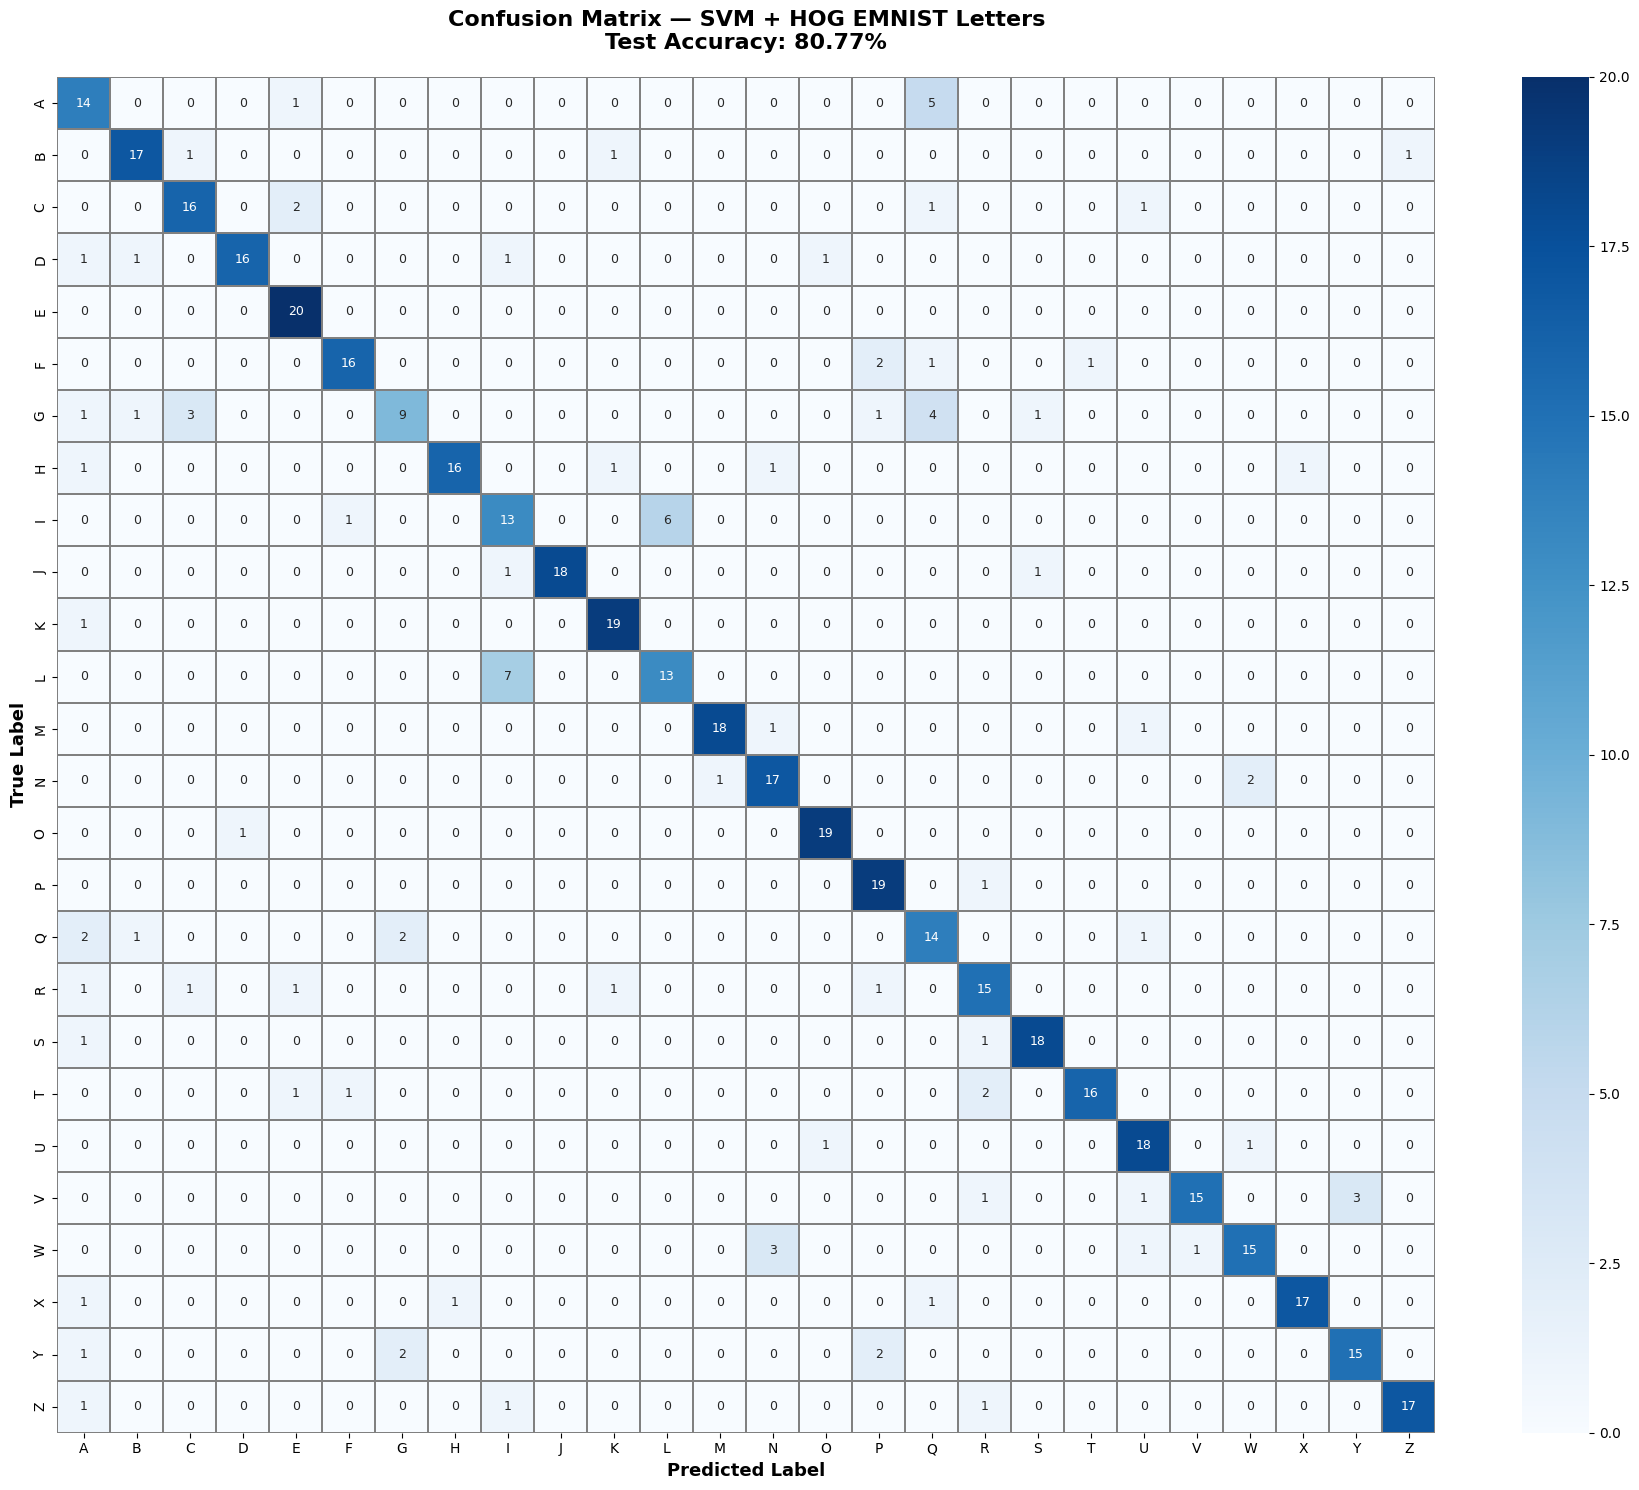

In [44]:
cm = confusion_matrix(y_test, y_test_pred)
target_names = [label_map[i] for i in range(1, 27)]

plt.figure(figsize=(18, 15))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    linewidths=0.3,
    linecolor='gray',
    annot_kws={"size": 9}
)

plt.title('Confusion Matrix — SVM + HOG EMNIST Letters\n'
          f'Test Accuracy: {test_acc*100:.2f}%', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Ringkasan Akhir ## 

In [ ]:
print("=" * 60)
print("            RINGKASAN EKSPERIMEN AKHIR")
print("=" * 60)

print(f"\n 1. DATASET")
print(f"   Dataset        : EMNIST Letters")
print(f"   Total sampel   : 2600 (26 kelas × 100 sampel)")
print(f"   Training set   : {len(X_train)} sampel (80%)")
print(f"   Testing set    : {len(X_test)} sampel (20%)")
print(f"   Split method   : LOOCV (Stratified 80/20)")

print(f"\n 2. HOG PARAMETERS")
print(f"   Orientations   : {HOG_ORIENTATIONS}  (default: 9)")
print(f"   Pixels/cell    : {HOG_PIXELS_PER_CELL}  (default: (8,8))")
print(f"   Cells/block    : {HOG_CELLS_PER_BLOCK}  (default: (3,3))")
print(f"   Block norm     : {HOG_BLOCK_NORM}")
print(f"   Total fitur    : {X.shape[1]}")

print(f"\n 3. SVM PARAMETERS (Best dari Grid Search)")
print(f"   Kernel         : {best_svm.kernel}")
print(f"   C              : {best_svm.C}")
print(f"   Gamma          : {best_svm.gamma}")
print(f"   Best CV Score  : {grid_search.best_score_*100:.2f}%")

print(f"\n 4. HASIL EVALUASI")
print(f"   {'Metric':<15} {'Train':>10} {'Test':>10}")
print(f"   {'-'*35}")
print(f"   {'Accuracy':<15} {train_acc*100:>9.2f}% {test_acc*100:>9.2f}%")
print(f"   {'Precision':<15} {train_prec*100:>9.2f}% {test_prec*100:>9.2f}%")
print(f"   {'Recall':<15} {train_rec*100:>9.2f}% {test_rec*100:>9.2f}%")
print(f"   {'F1-Score':<15} {train_f1*100:>9.2f}% {test_f1*100:>9.2f}%")
print("=" * 60)

            RINGKASAN EKSPERIMEN AKHIR

 1. DATASET
   Dataset        : EMNIST Letters
   Total sampel   : 2600 (26 kelas × 100 sampel)
   Training set   : 2080 sampel (80%)
   Testing set    : 520 sampel (20%)
   Split method   : LOOCV (Stratified 80/20)

 2. HOG PARAMETERS
   Orientations   : 12  (default: 9)
   Pixels/cell    : (7, 7)  (default: (8,8))
   Cells/block    : (2, 2)  (default: (3,3))
   Block norm     : L2-Hys
   Total fitur    : 432

 3. SVM PARAMETERS (Best dari Grid Search)
   Kernel         : rbf
   C              : 10
   Gamma          : scale
   Best CV Score  : 83.37%

 4. HASIL EVALUASI
   Metric               Train       Test
   -----------------------------------
   Accuracy           100.00%     80.77%
   Precision          100.00%     81.93%
   Recall             100.00%     80.77%
   F1-Score           100.00%     80.89%
